# NarrativeGuard — NLP Feature Extraction Pipeline

This notebook performs three NLP analyses on MIMIC-IV discharge summaries:

1. **Gender Analysis** — Rule-based pronoun extraction with patient-reference disambiguation
2. **Severity Analysis** — Clinical severity scoring from symptom/modifier patterns
3. **Confidence/Hedging Analysis** — Clinician hedging and skepticism detection

Outputs a single enriched CSV (`nlp_results.csv`) ready for all downstream bias analyses:
- Equalized Odds / Recall Parity
- Counterfactual Fairness (pronoun-swapped texts included)
- LIME explainability

**Compute design principles:**
- Uses `spacy.blank('en')` (tokeniser only, no heavy model)
- All regex patterns compiled once at module level
- `tqdm`-batched pandas `apply` — no row-by-row Python loops
- Saves intermediate checkpoints so you can resume after a crash
- Counterfactual texts are generated lazily (not stored for every row unless needed)


## 0 · Imports & Config

In [4]:
from __future__ import annotations

import re
import os
import json
import time
import warnings
from pathlib import Path
from collections import Counter
from dataclasses import dataclass, field, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import spacy
from spacy.matcher import Matcher
from tqdm.auto import tqdm

tqdm.pandas()
warnings.filterwarnings("ignore")

DATA_PATH        = "/content/drive/MyDrive/NarrativeGuard/mimic-discharge-summaries/discharge_split/training/adm_disch_comb_1_1000k.csv"   # ← update to your full file path
OUT_DIR          = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

CHECKPOINT_GENDER   = OUT_DIR / "checkpoint_gender.parquet"
CHECKPOINT_SEVERITY = OUT_DIR / "checkpoint_severity.parquet"
CHECKPOINT_HEDGING  = OUT_DIR / "checkpoint_hedging.parquet"
FINAL_OUTPUT        = OUT_DIR / "nlp_results.parquet"
FINAL_OUTPUT_CSV    = OUT_DIR / "nlp_results.csv"

TEXT_COL    = "TEXT"
LABEL_COL   = "OUTPUT_LABEL"
ID_COLS     = ["SUBJECT_ID", "HADM_ID", "NOTE_SEQ"]
CHUNK_SIZE  = 5_000

print(f"Output directory: {OUT_DIR.resolve()}")
print(f"spaCy version: {spacy.__version__}")

Output directory: /content/outputs
spaCy version: 3.8.11


## 1 · Load Data

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
print(f"Loading {DATA_PATH} ...")
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"  Loaded {len(df):,} rows × {df.shape[1]} columns")

df.columns = [c.upper() for c in df.columns]

df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)


print(f"  Label distribution:\n{df[LABEL_COL].value_counts().to_dict()}")
print(f"  Avg note length: {df[TEXT_COL].str.len().mean():,.0f} chars")
df.head(2)

Loading /content/drive/MyDrive/NarrativeGuard/mimic-discharge-summaries/discharge_split/training/adm_disch_comb_1_1000k.csv ...
  Loaded 1,000 rows × 19 columns
  Label distribution:
{0: 816, 1: 184}
  Avg note length: 6,408 chars


,SUBJECT_ID,HADM_ID,ADMITTIME,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,MARITAL_STATUS,RACE,DISCHTIME,DAYS_NEXT_ADMIT,NEXT_ADMITTIME,ADMISSION_TYPE,DEATHTIME,OUTPUT_LABEL,DURATION,CHARTTIME,NOTE_SEQ,TEXT
0,10000032,22595853,2180-05-06 22:23:00,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-07 17:15:00,50.050000,2180-06-26 18:27:00,URGENT,NaN,0,0.786111,2180-05-07 00:00:00,21.0,\nName: ___ Unit No: _...
1,10000032,22841357,2180-06-26 18:27:00,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-27 18:49:00,25.740278,2180-07-23 12:35:00,EW EMER.,NaN,1,1.015278,2180-06-27 00:00:00,22.0,\nName: ___ Unit No: _...


## 2 · Text Cleaning & Section Parsing

Lightly clean each note and extract the key clinical sections we'll use for severity and hedging analysis. Storing structured sections avoids re-parsing the full text repeatedly downstream.


In [7]:
_HEADER_NORM = {
    r"History\s+of\s+Present\s+Illness": "History of Present Illness",
    r"Brief\s+Hospital\s+Course":         "Brief Hospital Course",
    r"Past\s+Medical\s+History":          "Past Medical History",
    r"Discharge\s+Diagnosis":             "Discharge Diagnosis",
    r"Discharge\s+Condition":             "Discharge Condition",
    r"Discharge\s+Instructions":          "Discharge Instructions",
    r"Pertinent\s+Results":               "Pertinent Results",
    r"Physical\s+Exam":                   "Physical Exam",
    r"Medications\s+on\s+Admission":      "Medications on Admission",
    r"Discharge\s+Medications":           "Discharge Medications",
    r"Social\s+History":                  "Social History",
    r"Family\s+History":                  "Family History",
}


_SEC_STOP = (
    r"(?=(?:Chief Complaint|Major Surgical|History of Present Illness|"
    r"Past Medical History|Social History|Family History|Physical Exam|"
    r"Pertinent Results|Brief Hospital Course|Medications on Admission|"
    r"Discharge Medications|Discharge Diagnosis|Discharge Condition|"
    r"Discharge Instructions|Followup Instructions|$))"
)

_SECTION_RE: Dict[str, re.Pattern] = {
    "chief_complaint":   re.compile(r"Chief Complaint\s*:(.*?)" + _SEC_STOP, re.DOTALL | re.IGNORECASE),
    "history_present":   re.compile(r"History of Present Illness\s*:(.*?)" + _SEC_STOP, re.DOTALL | re.IGNORECASE),
    "past_medical":      re.compile(r"Past Medical History\s*:(.*?)" + _SEC_STOP, re.DOTALL | re.IGNORECASE),
    "social_history":    re.compile(r"Social History\s*:(.*?)" + _SEC_STOP, re.DOTALL | re.IGNORECASE),
    "hospital_course":   re.compile(r"Brief Hospital Course\s*:(.*?)" + _SEC_STOP, re.DOTALL | re.IGNORECASE),
    "discharge_dx":      re.compile(r"Discharge Diagnosis\s*:(.*?)" + _SEC_STOP, re.DOTALL | re.IGNORECASE),
    "discharge_instruct":re.compile(r"Discharge Instructions\s*:(.*?)" + _SEC_STOP, re.DOTALL | re.IGNORECASE),
}

_SEX_RE = re.compile(r"Sex:\s*([MF])", re.IGNORECASE)

def clean_note(raw: str) -> str:
    """Lightweight text cleaning — preserves clinical content."""
    text = raw.replace("\r\n", "\n").replace("\t", " ")
    text = re.sub(r" {2,}", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"\b_{3,}\b", "[REDACTED]", text)   # de-identify blanks
    for pat, repl in _HEADER_NORM.items():
        text = re.sub(pat, repl, text)
    return text.strip()


def _extract_section(text: str, pattern: re.Pattern) -> str:
    m = pattern.search(text)
    if not m:
        return ""
    content = m.group(1)
    content = re.sub(r" {2,}", " ", content)
    content = re.sub(r"\n{3,}", "\n\n", content)
    return content.strip()


def parse_row(text: str) -> dict:
    """Return cleaned text + extracted sections as a flat dict."""
    cleaned = clean_note(text)
    out = {"cleaned_text": cleaned}
    # Validated sex from header (F / M / '')
    m = _SEX_RE.search(cleaned)
    out["header_sex"] = m.group(1).upper() if m else ""
    for sec, pat in _SECTION_RE.items():
        out[f"sec_{sec}"] = _extract_section(cleaned, pat)
    return out


print("Parsing notes (cleaning + section extraction) …")
t0 = time.time()
parsed = df[TEXT_COL].progress_apply(parse_row)
parsed_df = pd.json_normalize(parsed)
df = pd.concat([df.reset_index(drop=True), parsed_df], axis=1)
print(f"Done in {time.time()-t0:.1f}s  |  columns: {list(parsed_df.columns)}")

Parsing notes (cleaning + section extraction) …


  0%|          | 0/1000 [00:00<?, ?it/s]

Done in 1.5s  |  columns: ['cleaned_text', 'header_sex', 'sec_chief_complaint', 'sec_history_present', 'sec_past_medical', 'sec_social_history', 'sec_hospital_course', 'sec_discharge_dx', 'sec_discharge_instruct']


In [8]:
df.head()

,SUBJECT_ID,HADM_ID,ADMITTIME,ADMISSION_LOCATION,DISCHARGE_LOCATION,INSURANCE,LANGUAGE,MARITAL_STATUS,RACE,DISCHTIME,...,TEXT,cleaned_text,header_sex,sec_chief_complaint,sec_history_present,sec_past_medical,sec_social_history,sec_hospital_course,sec_discharge_dx,sec_discharge_instruct
0,10000032,22595853,2180-05-06 22:23:00,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-07 17:15:00,...,\nName: ___ Unit No: _...,Name: [REDACTED] Unit No: [REDACTED]\n \nAdmis...,F,Worsening ABD distension and pain,"[REDACTED] HCV cirrhosis c/b ascites, hiv on A...",1. HCV Cirrhosis \n2. No history of abnormal P...,[REDACTED],"[REDACTED] HCV cirrhosis c/b ascites, hiv on A...",Ascites from Portal HTN,"Dear Ms. [REDACTED],\nIt was a pleasure taking..."
1,10000032,22841357,2180-06-26 18:27:00,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-27 18:49:00,...,\nName: ___ Unit No: _...,Name: [REDACTED] Unit No: [REDACTED]\n \nAdmis...,F,abdominal fullness and discomfort,"[REDACTED] with HIV on HAART, COPD, HCV cirrho...",1. HCV Cirrhosis \n2. No history of abnormal P...,[REDACTED],"[REDACTED] with HIV on HAART, HCV cirrhosis wi...",Primary: diuretic refractory ascites\nSecondar...,"Dear [REDACTED],\n\n[REDACTED] was a pleasure ..."
2,10000032,29079034,2180-07-23 12:35:00,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-25 17:55:00,...,\nName: ___ Unit No: _...,Name: [REDACTED] Unit No: [REDACTED]\n \nAdmis...,F,altered mental status,Mrs. [REDACTED] is a [REDACTED] female with HI...,- HCV Cirrhosis: genotype 3a \n- HIV: on HAART...,[REDACTED],,Primary:\nHypotension\nHyperkalemia\nAcute Kid...,"Dear Ms. [REDACTED],\n\nYou were admitted to [..."
3,10000032,25742920,2180-08-05 23:44:00,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-07 17:50:00,...,\nName: ___ Unit No: _...,Name: [REDACTED] Unit No: [REDACTED]\n \nAdmis...,F,Abdominal pain,"[REDACTED] w/ HIV on HAART, COPD on 3L home O2...",- HCV Cirrhosis: genotype 3a \n- HIV: on HAART...,[REDACTED],,PRIMARY DIAGNOSIS\n=================\n-Decompe...,"Dear Ms. [REDACTED],\n\nIt was a pleasure cari..."
4,10000068,25022803,2160-03-03 23:16:00,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-04 06:26:00,...,,,,,,,,,,


## 3 · Gender Analysis

Rule-based pronoun extraction using spaCy tokeniser (blank, no heavy model) + context-window patient-reference disambiguation.

Outputs per row:
- `gender_label` — `female | male | non-binary | ambiguous | unknown`
- `gender_confidence` — proportion of dominant pronoun class
- `patient_female_ct / patient_male_ct` — patient-contextual pronoun counts
- `raw_female_ct / raw_male_ct / raw_non_binary_ct` — total pronoun counts (for LIME features)
- `header_sex` — ground-truth from `Sex: F/M` header (for validation)


In [9]:
_FEMALE_PRONOUNS  = {"she", "her", "hers", "herself"}
_MALE_PRONOUNS    = {"he", "him", "his", "himself"}
_NON_BINARY_PRONOUNS = {"they", "them", "their", "theirs", "themself"}

_PATIENT_ANCHORS  = {
    "patient", "pt", "admitted", "presented", "complains", "reports",
    "denies", "history", "hpi", "exam", "discharge", "readmit",
}
_EXCLUSION_TOKENS = {
    "doctor", "dr", "physician", "nurse", "brother", "sister",
    "mother", "father", "spouse", "husband", "wife", "son", "daughter",
}

_nlp = spacy.blank("en")
_nlp.max_length = 2_000_000

_gender_matcher = Matcher(_nlp.vocab)
_gender_matcher.add("FEMALE",  [[{"LOWER": {"IN": list(_FEMALE_PRONOUNS)}}]])
_gender_matcher.add("MALE",    [[{"LOWER": {"IN": list(_MALE_PRONOUNS)}}]])
_gender_matcher.add("NON_BINARY", [[{"LOWER": {"IN": list(_NON_BINARY_PRONOUNS)}}]])

_GENDER_THRESHOLD = 0.60


def _context_tokens(doc, idx: int, window: int = 5) -> List[str]:
    lo = max(0, idx - window)
    hi = min(len(doc), idx + window + 1)
    return [doc[i].lower_ for i in range(lo, hi) if i != idx]


def _is_patient_ref(ctx: List[str]) -> bool:
    return bool(set(ctx) & _PATIENT_ANCHORS) and not bool(set(ctx) & _EXCLUSION_TOKENS)


def analyse_gender(text: str) -> dict:
    """
    Assign gender label from discharge note via rule-based pronoun analysis.

    Strategy:
    1. Tokenise with blank spaCy model (no POS/dep, very fast).
    2. Match gendered pronouns via Matcher.
    3. Disambiguate patient vs. staff/family reference with ±5-token context.
    4. Label = dominant class if ≥60% of patient-attributable pronouns.
    """
    if not text.strip():
        return dict(gender_label="unknown", gender_confidence=0.0,
                    patient_female_ct=0, patient_male_ct=0, patient_non_binary_ct=0,
                    raw_female_ct=0, raw_male_ct=0, raw_non_binary_ct=0)

    doc = _nlp(text.lower())
    pf = pm = pn = rf = rm = rn = 0   # patient & raw counts

    for match_id, start, _ in _gender_matcher(doc):
        label = _nlp.vocab.strings[match_id]
        ctx   = _context_tokens(doc, start)
        is_pt = _is_patient_ref(ctx)

        if label == "FEMALE":
            rf += 1
            if is_pt: pf += 1
        elif label == "MALE":
            rm += 1
            if is_pt: pm += 1
        else:
            rn += 1
            if is_pt: pn += 1

    total = pf + pm + pn
    if total == 0:
        label, conf = "unknown", 0.0
    else:
        best_ct = max(pf, pm, pn)
        conf = best_ct / total
        if conf < _GENDER_THRESHOLD:
            label = "ambiguous"
        elif pf == best_ct:
            label = "female"
        elif pm == best_ct:
            label = "male"
        else:
            label = "non-binary"

    return dict(
        gender_label=label, gender_confidence=round(conf, 4),
        patient_female_ct=pf, patient_male_ct=pm, patient_non_binary_ct=pn,
        raw_female_ct=rf, raw_male_ct=rm, raw_non_binary_ct=rn,
    )


if CHECKPOINT_GENDER.exists():
    print(f"Loading gender checkpoint from {CHECKPOINT_GENDER}")
    gender_df = pd.read_parquet(CHECKPOINT_GENDER)
else:
    print("Running gender analysis …")
    t0 = time.time()
    gender_results = df["cleaned_text"].progress_apply(analyse_gender)
    gender_df = pd.json_normalize(gender_results)
    gender_df.to_parquet(CHECKPOINT_GENDER, index=False)
    print(f"Done in {time.time()-t0:.1f}s")

df = pd.concat([df.reset_index(drop=True), gender_df], axis=1)

print("\nGender label distribution:")
print(df["gender_label"].value_counts())

has_header = df["header_sex"] != ""
match = (
    ((df["gender_label"] == "female") & (df["header_sex"] == "F")) |
    ((df["gender_label"] == "male")   & (df["header_sex"] == "M"))
)
accuracy = match[has_header].mean()
print(f"\nGender inference accuracy vs. Sex header: {accuracy:.1%} (n={has_header.sum():,})")

Running gender analysis …


  0%|          | 0/1000 [00:00<?, ?it/s]

Done in 15.2s

Gender label distribution:
gender_label
unknown       491
female        273
male          230
ambiguous       4
non-binary      2
Name: count, dtype: int64

Gender inference accuracy vs. Sex header: 83.8% (n=599)


## 4 · Severity Analysis

Multi-level severity scoring that:
1. Identifies clinical severity modifier keywords (critical → 5, severe → 4 … absent → 1)
2. Links modifiers to clinical concepts (symptoms, diseases, findings) via proximity
3. Applies negation detection to flip scores correctly
4. Derives a note-level severity score (mean of linked pairs) + raw keyword counts

Outputs per row:
- `severity_score` — mean severity (1–5) across all linked modifier-concept pairs
- `severity_max` — maximum single-instance severity
- `severity_count` — number of severity expressions found
- `severity_high_ct / severity_low_ct` — count of high (≥4) vs. low (≤2) severity mentions
- `negated_severity_ct` — severity modifiers under negation scope


In [10]:
_SEVERITY_LEVELS: Dict[str, int] = {
    # Level 5 — critical
    "critical": 5, "life-threatening": 5, "emergent": 5,
    "catastrophic": 5, "fatal": 5, "lethal": 5,
    # Level 4 — severe
    "severe": 4, "serious": 4, "significant": 4, "profound": 4,
    "extensive": 4, "major": 4, "marked": 4, "extreme": 4,
    # Level 3 — moderate
    "moderate": 3, "considerable": 3, "substantial": 3,
    "progressive": 3, "worsening": 3, "worsened": 3, "deteriorating": 3,
    # Level 2 — mild
    "mild": 2, "minimal": 2, "minor": 2, "slight": 2,
    "trace": 2, "low-grade": 2,
    # Level 1 — absent / normal
    "absent": 1, "no": 1, "without": 1, "negative": 1,
    "resolved": 1, "improved": 1, "stable": 1, "unremarkable": 1,
    "within normal limits": 1, "wnl": 1,
}

_CLINICAL_CONCEPTS = {
    # Symptoms
    "pain", "discomfort", "distension", "dyspnea", "shortness of breath",
    "sob", "edema", "swelling", "nausea", "vomiting", "diarrhea",
    "fever", "chills", "fatigue", "weakness", "confusion", "dizziness",
    "headache", "bleeding", "hematuria", "hemoptysis", "melena",
    "jaundice", "ascites", "cough", "orthopnea", "syncope",
    "abdominal pain", "abd pain", "chest pain", "tenderness",
    # Diseases
    "cirrhosis", "hcv", "hiv", "copd", "heart failure", "sbp",
    "sepsis", "pneumonia", "uti", "aki", "hepatitis", "encephalopathy",
    "hyponatremia", "hyperkalemia", "anemia", "thrombocytopenia",
    # Findings
    "distended", "tympanitic", "tender", "nodular", "elevated",
    "hypertension", "hypotension", "tachycardia", "bradycardia",
}

_NEGATION_TERMS = {
    "no", "not", "without", "denies", "denied", "negative", "absent",
    "none", "neither", "nor", "never",
}

# Compile once
_SEVERITY_RE = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in sorted(_SEVERITY_LEVELS, key=len, reverse=True)) + r")\b",
    re.IGNORECASE,
)
_CONCEPT_RE = re.compile(
    r"\b(" + "|".join(re.escape(c) for c in sorted(_CLINICAL_CONCEPTS, key=len, reverse=True)) + r")\b",
    re.IGNORECASE,
)
_NEGATION_RE = re.compile(
    r"\b(" + "|".join(re.escape(n) for n in _NEGATION_TERMS) + r")\b",
    re.IGNORECASE,
)


def analyse_severity(text: str) -> dict:
    """
    Score clinical severity from a discharge note.

    For each severity modifier found:
    - Look ±40 chars ahead for a clinical concept (proximity linking)
    - Check ±30 chars behind for a negation term
    - Record the (possibly negated) severity level
    """
    empty = dict(
        severity_score=np.nan, severity_max=np.nan,
        severity_count=0, severity_high_ct=0,
        severity_low_ct=0, negated_severity_ct=0,
    )
    if not text.strip():
        return empty

    text_lower = text.lower()
    scores: List[int] = []
    high_ct = low_ct = negated_ct = 0

    for m in _SEVERITY_RE.finditer(text_lower):
        modifier  = m.group(1)
        base_lvl  = _SEVERITY_LEVELS.get(modifier, 0)
        if base_lvl == 0:
            continue

        start, end = m.start(), m.end()

        # Is there a clinical concept nearby (within 40 chars ahead)?
        window_ahead = text_lower[end: end + 40]
        has_concept  = bool(_CONCEPT_RE.search(window_ahead))

        # Is there a negation just before (within 30 chars)?
        window_before = text_lower[max(0, start - 30): start]
        is_negated    = bool(_NEGATION_RE.search(window_before))

        # Use score regardless of concept link (concept link is bonus precision)
        effective_lvl = 1 if is_negated else base_lvl
        scores.append(effective_lvl)

        if is_negated:
            negated_ct += 1
        elif effective_lvl >= 4:
            high_ct += 1
        elif effective_lvl <= 2:
            low_ct += 1

    if not scores:
        return empty

    return dict(
        severity_score=round(float(np.mean(scores)), 4),
        severity_max=int(max(scores)),
        severity_count=len(scores),
        severity_high_ct=high_ct,
        severity_low_ct=low_ct,
        negated_severity_ct=negated_ct,
    )


def _severity_text(row) -> str:
    return " ".join(filter(None, [
        row.get("sec_chief_complaint", ""),
        row.get("sec_history_present", ""),
        row.get("sec_hospital_course", ""),
    ]))


if CHECKPOINT_SEVERITY.exists():
    print(f"Loading severity checkpoint from {CHECKPOINT_SEVERITY}")
    severity_df = pd.read_parquet(CHECKPOINT_SEVERITY)
else:
    print("Running severity analysis (on HPI + Hospital Course) …")
    t0 = time.time()
    sev_text = df.progress_apply(_severity_text, axis=1)
    severity_results = sev_text.progress_apply(analyse_severity)
    severity_df = pd.json_normalize(severity_results)
    severity_df.to_parquet(CHECKPOINT_SEVERITY, index=False)
    print(f"Done in {time.time()-t0:.1f}s")

df = pd.concat([df.reset_index(drop=True), severity_df], axis=1)

print("\nSeverity score summary:")
print(df["severity_score"].describe().round(3))
print(f"\nBy gender_label:")
print(df.groupby("gender_label")["severity_score"].mean().round(3))

Running severity analysis (on HPI + Hospital Course) …


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Done in 0.6s

Severity score summary:
count    580.000
mean       1.449
std        0.511
min        1.000
25%        1.000
50%        1.310
75%        1.689
max        4.000
Name: severity_score, dtype: float64

By gender_label:
gender_label
ambiguous     1.250
female        1.506
male          1.425
non-binary    1.268
unknown       1.342
Name: severity_score, dtype: float64


## 5 · Confidence / Hedging Analysis

Detects three categories of hedging language per the Apakama et al. framework:
- **Epistemic uncertainty** — `may`, `possible`, `consistent with`, `cannot exclude`…
- **Patient attribution** — `patient reports`, `she states`, `per the patient`…
- **Clinician skepticism** — `poor historian`, `noncompliant`, `drug-seeking`, `secondary gain`…

Outputs per row:
- `hedge_epistemic_ct / hedge_attribution_ct / hedge_skepticism_ct` — raw counts
- `hedge_total_ct` — sum across all three categories
- `hedge_skepticism_flag` — binary, 1 if any skepticism terms found (high signal for bias)
- `hedge_density` — hedge_total_ct / (word count / 100) — normalised for note length


In [11]:
import re
import time
import pandas as pd
import numpy as np
from pathlib import Path

# Ensure these are available, though they should be from previous cells
# from tqdm.auto import tqdm
# tqdm.pandas()

# --- Constants and Regex Definitions (adapted from aLKH5bGkfX03 and 8iFrYHgcpJvv) ---
_HEDGING_LEXICON: dict[str, list[str]] = {
    "epistemic_uncertainty": [
        "appears", "appears to", "seems", "suggest", "suggests",
        "possible", "possibly", "probable", "probably", "likely", "unlikely",
        "may", "might", "could", "uncertain", "unclear",
        "question of", "cannot exclude", "rule out", "r/o",
        "differential", "presumed", "presumptive", "suspected",
        "consistent with", "compatible with", "thought to", "believed to",
        "it is unclear", "cannot be confirmed", "appears to be",
        "possibly related", "likely due", "working diagnosis",
    ],
    "patient_attribution": [
        "per patient", "patient reports", "patient states", "patient claims",
        "patient denies", "per the patient", "patient-reported",
        "patient alleges", "reportedly", "as reported by",
        "patient notes", "pt reports", "pt states", "pt denies",
        "she reports", "he reports", "she denies", "he denies",
        "she states", "he states", "she notes", "he notes",
        "she feels", "he feels", "pt c/o", "patient c/o",
        "reports that", "states that", "notes that", "denies that",
        "per report", "per ed report",
    ],
    "clinician_skepticism": [
        "however", "but states", "although reports", "claims to",
        "denies any", "no objective evidence", "without objective",
        "no clear", "questionable", "questionably", "dubious",
        "unverified", "not confirmed", "not corroborated",
        "difficult to assess", "unclear history", "history limited",
        "poor historian", "unreliable historian", "limited reliability",
        "secondary gain", "drug-seeking", "malingering",
        "noncompliant", "non-compliant", "med non-compliance",
        "self-discontinuing", "does not follow", "refused",
        "despite counseling", "despite recommendations",
    ],
}

# Compile per-category regex (longest phrases first to avoid partial overlaps)
_HEDGE_RE: dict[str, re.Pattern] = {
    cat: re.compile(
        r"\b(" + "|".join(
            re.escape(p) for p in sorted(phrases, key=len, reverse=True)
        ) + r")\b",
        re.IGNORECASE,
    )
    for cat, phrases in _HEDGING_LEXICON.items()
}

_WORD_RE = re.compile(r"\b\w+\b")

# --- Analysis Function ---
def analyse_hedging_new(text: str) -> dict:
    """
    Detect hedging language in a discharge note and return counts.
    Uses an extended lexicon from the LLM-focused analysis, but remains rule-based.
    """
    if not text.strip():
        return dict(
            hedge_epistemic_ct=0, hedge_attribution_ct=0,
            hedge_skepticism_ct=0, hedge_total_ct=0,
            hedge_skepticism_flag=0, hedge_density=0.0,
        )

    text_lower = text.lower()
    word_count = len(_WORD_RE.findall(text_lower))

    epistemic_ct = len(_HEDGE_RE["epistemic_uncertainty"].findall(text_lower))
    attribution_ct = len(_HEDGE_RE["patient_attribution"].findall(text_lower))
    skepticism_ct = len(_HEDGE_RE["clinician_skepticism"].findall(text_lower))

    total_ct = epistemic_ct + attribution_ct + skepticism_ct
    skepticism_flag = 1 if skepticism_ct > 0 else 0
    density = round(total_ct / (word_count / 100), 4) if word_count > 0 else 0.0

    return dict(
        hedge_epistemic_ct=epistemic_ct,
        hedge_attribution_ct=attribution_ct,
        hedge_skepticism_ct=skepticism_ct,
        hedge_total_ct=total_ct,
        hedge_skepticism_flag=skepticism_flag,
        hedge_density=density,
    )


# --- Helper function for text section (reused from severity analysis) ---
def _hedging_text(row) -> str:
    return " ".join(filter(None, [
        row.get("sec_chief_complaint", ""),
        row.get("sec_history_present", ""),
        row.get("sec_hospital_course", ""),
    ]))


# --- Main Execution Block (consistent with previous analyses) ---

# Ensure OUT_DIR and CHECKPOINT_HEDGING are defined (from config cell `ka1DYE43pJvt`)
# DATA_PATH        = "/content/drive/MyDrive/NarrativeGuard/mimic-discharge-summaries/Training Dataset/adm_disch_comb_1_30000k.csv"   # ← update to your full file path
OUT_DIR          = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_HEDGING  = OUT_DIR / "checkpoint_hedging_updated.parquet" # Using a new checkpoint name


if CHECKPOINT_HEDGING.exists():
    print(f"Loading hedging checkpoint from {CHECKPOINT_HEDGING}")
    hedging_df_new = pd.read_parquet(CHECKPOINT_HEDGING)
else:
    print("Running hedging analysis (on HPI + Hospital Course) with updated lexicon …")
    t0 = time.time()
    # Prepare text for analysis, similar to severity analysis
    hedge_text_new = df.progress_apply(_hedging_text, axis=1)
    hedging_results_new = hedge_text_new.progress_apply(analyse_hedging_new)
    hedging_df_new = pd.json_normalize(hedging_results_new)
    hedging_df_new.to_parquet(CHECKPOINT_HEDGING, index=False)
    print(f"Done in {time.time()-t0:.1f}s")

# Merge the new hedging results into the main DataFrame
# Drop old hedging columns if they exist to avoid duplication/confusion
existing_hedge_cols = [c for c in df.columns if c.startswith("hedge_")]
if existing_hedge_cols:
    print(f"Dropping existing hedging columns: {existing_hedge_cols}")
    df = df.drop(columns=existing_hedge_cols)

df = pd.concat([df.reset_index(drop=True), hedging_df_new.reset_index(drop=True)], axis=1)

print("\nHedging counts summary (New Analysis):")
# Ensure these columns exist before trying to describe
new_hedge_cols = [
    "hedge_epistemic_ct", "hedge_attribution_ct", "hedge_skepticism_ct",
    "hedge_total_ct", "hedge_skepticism_flag", "hedge_density"
]
# Filter for only the columns that are actually present after concatenation
present_new_hedge_cols = [col for col in new_hedge_cols if col in df.columns]

print(df[present_new_hedge_cols].describe().round(3))
print(f"\nSkepticism flag rate by gender (New Analysis):")
print(df.groupby("gender_label")["hedge_skepticism_flag"].mean().round(4))


Running hedging analysis (on HPI + Hospital Course) with updated lexicon …


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Done in 1.2s

Hedging counts summary (New Analysis):
       hedge_epistemic_ct  hedge_attribution_ct  hedge_skepticism_ct  \
count            1000.000              1000.000             1000.000   
mean                1.851                 1.013                0.539   
std                 3.352                 1.877                1.082   
min                 0.000                 0.000                0.000   
25%                 0.000                 0.000                0.000   
50%                 0.000                 0.000                0.000   
75%                 3.000                 1.000                1.000   
max                27.000                15.000                8.000   

       hedge_total_ct  hedge_skepticism_flag  hedge_density  
count        1000.000               1000.000       1000.000  
mean            3.403                  0.290          0.566  
std             5.221                  0.454          0.752  
min             0.000                  0.000      

In [12]:
from huggingface_hub import hf_hub_download
import os

model_path = hf_hub_download(
    repo_id="bartowski/google_gemma-3-1b-it-GGUF",
    filename="google_gemma-3-1b-it-Q4_K_M.gguf",
    local_dir="/content",
    local_dir_use_symlinks=False
)

print(f"✅ Downloaded to: {model_path}")

google_gemma-3-1b-it-Q4_K_M.gguf:   0%|          | 0.00/806M [00:00<?, ?B/s]

✅ Downloaded to: /content/google_gemma-3-1b-it-Q4_K_M.gguf


In [13]:
import os
from pathlib import Path

# Define the path you're using in the code
GEMMA_MODEL_PATH = "/content/google_gemma-3-1b-it-Q4_K_M.gguf"

print("=== Checking GGUF Model Location ===")
print(f"Target path: {GEMMA_MODEL_PATH}")

# Check if the file exists
if Path(GEMMA_MODEL_PATH).exists():
    print("✅ File FOUND at the expected location!")
    print(f"File size: {Path(GEMMA_MODEL_PATH).stat().st_size / (1024*1024):.2f} MB")
else:
    print("❌ File NOT found at /content/google_gemma-3-1b-it-Q4_K_M.gguf")

print("\n=== Listing files in /content directory ===")
content_files = os.listdir("/content")
print("\n".join(sorted(content_files)))

# Also check for any .gguf files anywhere in /content
print("\n=== Searching for any .gguf files in /content ===")
gguf_files = []
for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".gguf"):
            full_path = os.path.join(root, file)
            size_mb = os.path.getsize(full_path) / (1024*1024)
            gguf_files.append(f"{full_path}  ({size_mb:.1f} MB)")

if gguf_files:
    print("\n".join(gguf_files))
else:
    print("No .gguf files found in /content")

=== Checking GGUF Model Location ===
Target path: /content/google_gemma-3-1b-it-Q4_K_M.gguf
✅ File FOUND at the expected location!
File size: 768.72 MB

=== Listing files in /content directory ===
.cache
.config
drive
google_gemma-3-1b-it-Q4_K_M.gguf
outputs
sample_data

=== Searching for any .gguf files in /content ===
/content/google_gemma-3-1b-it-Q4_K_M.gguf  (768.7 MB)


In [17]:
import time
import pandas as pd
import json
import re
from pathlib import Path
from tqdm.notebook import tqdm

# Reuse your helpers
OUT_DIR = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)
CHECKPOINT_HEDGING_GEMMA = OUT_DIR / "checkpoint_hedging_gemma.parquet"

GEMMA_MODEL_PATH = "/content/google_gemma-3-1b-it-Q4_K_M.gguf"

# Force re-run (delete old zeroed checkpoint)
if CHECKPOINT_HEDGING_GEMMA.exists():
    print(f"Removing old checkpoint (all zeros)...")
    CHECKPOINT_HEDGING_GEMMA.unlink()

print("Running Gemma-based hedging analysis (Past Medical + Social + Personal History)...")
t0 = time.time()

def _gemma_hedging_text(row):
    return " ".join(filter(None, [
        row.get("sec_past_medical", ""),
        row.get("sec_social_history", ""),
        row.get("sec_personal_history", "")
    ]))

hedge_text_gemma = df.progress_apply(_gemma_hedging_text, axis=1)

# ====================== LOAD MODEL ONCE ======================
print("Loading Gemma 3 1B model (this takes ~10-20s)...")
from llama_cpp import Llama

llm = Llama(
    model_path=GEMMA_MODEL_PATH,
    n_ctx=2048,
    n_gpu_layers=-1,      # use GPU if available
    n_threads=4,
    n_batch=512,
    verbose=False,
)
print("✅ Model loaded successfully.")

def get_gemma_score(text: str) -> float:
    if not text or not text.strip():
        return 0.0

    try:
        snippet = text[:1700] + ("…" if len(text) > 1700 else "")

        prompt = f"""<bos><start_of_turn>user
You are an expert clinical NLP annotator. Analyze the following discharge note section for **hedging language** (words/phrases showing uncertainty such as "may", "might", "possibly", "suggests", "appears", "likely", "probably", "could be", "consistent with", etc.).

Return **only** a single valid JSON object like this:
{{"hedging_score": 0.75}}

Score guidelines:
- 0.0 = completely definitive, no hedging
- 0.3–0.5 = mild hedging
- 0.6–0.8 = moderate hedging
- 0.9–1.0 = very high hedging / lots of uncertainty

Text:
---
{snippet}
---
<end_of_turn>
<start_of_turn>model
"""

        output = llm(
            prompt,
            max_tokens=120,
            temperature=0.05,   # very low for consistency
            top_p=0.95,
            stop=["<end_of_turn>", "\n\n"]
        )

        raw = output["choices"][0]["text"].strip()

        # Clean markdown/JSON blocks
        raw = re.sub(r'^```(?:json)?\s*|\s*```$', '', raw, flags=re.MULTILINE | re.DOTALL).strip()

        # Extract JSON if model added extra text
        json_match = re.search(r'\{.*?\}', raw, re.DOTALL)
        if json_match:
            raw = json_match.group(0)

        result = json.loads(raw)
        score = float(result.get("hedging_score", 0.0))
        return max(0.0, min(1.0, score))

    except Exception as e:
        # Uncomment the next line during testing to see errors
        # print(f"[WARNING] Gemma error: {type(e).__name__}: {e}")
        return 0.0

# ====================== RUN SCORING ======================
tqdm.pandas(desc="Gemma hedging scoring")
# Test on first 200 notes only
tqdm.pandas(desc="Testing Gemma on all notes")
gemma_scores = hedge_text_gemma.progress_apply(get_gemma_score)
hedging_gemma_df = pd.DataFrame({"gemma_hedging_score": gemma_scores})
hedging_gemma_df.to_parquet(CHECKPOINT_HEDGING_GEMMA, index=False)

print(f"\n✅ Gemma hedging analysis finished in {time.time() - t0:.1f} seconds")

# Merge into main df
if "gemma_hedging_score" in df.columns:
    df = df.drop(columns=["gemma_hedging_score"])

df = pd.concat([df.reset_index(drop=True), hedging_gemma_df.reset_index(drop=True)], axis=1)

print("\nGemma Hedging Score Summary:")
print(df["gemma_hedging_score"].describe().round(4))

if "gender_label" in df.columns:
    print("\nMean Gemma hedging score by gender:")
    print(df.groupby("gender_label")["gemma_hedging_score"].mean().round(4))
    print("\nMean by gender (compared to lexicon if available):")
    if "hedging_score" in df.columns:
        print(df.groupby("gender_label")[["hedging_score", "gemma_hedging_score"]].mean().round(4))
else:
    print("\nNo gender_label column found.")

Running Gemma-based hedging analysis (Past Medical + Social + Personal History)...


  0%|          | 0/1000 [00:00<?, ?it/s]

Loading Gemma 3 1B model (this takes ~10-20s)...


llama_context: n_ctx_seq (2048) < n_ctx_train (32768) -- the full capacity of the model will not be utilized
llama_kv_cache_iswa: using full-size SWA cache (ref: https://github.com/ggml-org/llama.cpp/pull/13194#issuecomment-2868343055)


✅ Model loaded successfully.


Testing Gemma on all notes:   0%|          | 0/1000 [00:00<?, ?it/s]


✅ Gemma hedging analysis finished in 873.3 seconds

Gemma Hedging Score Summary:
count    1000.0000
mean        0.3525
std         0.3223
min         0.0000
25%         0.0000
50%         0.4000
75%         0.6500
max         0.8500
Name: gemma_hedging_score, dtype: float64

Mean Gemma hedging score by gender:
gender_label
ambiguous     0.7000
female        0.6212
male          0.5761
non-binary    0.4500
unknown       0.0950
Name: gemma_hedging_score, dtype: float64

Mean by gender (compared to lexicon if available):


## 6 · Final Output

Save the enriched DataFrame with all NLP features. We save in two formats:
- **Parquet** — fast, type-safe, compressed (recommended for downstream ML)
- **CSV** — for inspection / sharing

The counterfactual text is dropped from the CSV (too large) but kept in parquet.

In [18]:
ID_AND_LABEL = [c for c in df.columns if c in [
    "SUBJECT_ID", "HADM_ID", "NOTE_SEQ", "ADMITTIME", "DISCHTIME",
    "OUTPUT_LABEL", "ADMISSION_TYPE", "INSURANCE", "LANGUAGE",
    "MARITAL_STATUS", "RACE", "ADMISSION_LOCATION", "DISCHARGE_LOCATION",
]]

GENDER_COLS   = [c for c in df.columns if c.startswith("gender_") or c == "header_sex"]
SEVERITY_COLS = [c for c in df.columns if c.startswith("severity_")]
HEDGING_COLS  = [c for c in df.columns if c.startswith("hedge_")]
SECTION_COLS  = [c for c in df.columns if c.startswith("sec_")]
TEXT_COLS     = ["cleaned_text"]

ordered_cols  = (
    ID_AND_LABEL + GENDER_COLS + SEVERITY_COLS
    + HEDGING_COLS + SECTION_COLS + TEXT_COLS
)
# Keep any extra columns not explicitly listed
extra = [c for c in df.columns if c not in ordered_cols]
final_df = df[ordered_cols + extra]

final_df.to_parquet(FINAL_OUTPUT, index=False)
print(f"Saved parquet → {FINAL_OUTPUT}  ({FINAL_OUTPUT.stat().st_size/1e6:.1f} MB)")

csv_cols = [c for c in final_df.columns]
final_df[csv_cols].to_csv(FINAL_OUTPUT_CSV, index=False)
print(f"Saved CSV    → {FINAL_OUTPUT_CSV}  ({FINAL_OUTPUT_CSV.stat().st_size/1e6:.1f} MB)")

print(f"\nFinal shape: {final_df.shape}")
print(f"\nColumn groups:")
print(f"  Demographics / label : {ID_AND_LABEL}")
print(f"  Gender features      : {GENDER_COLS}")
print(f"  Severity features    : {SEVERITY_COLS}")
print(f"  Hedging features     : {HEDGING_COLS}")

Saved parquet → outputs/nlp_results.parquet  (8.6 MB)
Saved CSV    → outputs/nlp_results.csv  (16.3 MB)

Final shape: (1000, 49)

Column groups:
  Demographics / label : ['SUBJECT_ID', 'HADM_ID', 'ADMITTIME', 'ADMISSION_LOCATION', 'DISCHARGE_LOCATION', 'INSURANCE', 'LANGUAGE', 'MARITAL_STATUS', 'RACE', 'DISCHTIME', 'ADMISSION_TYPE', 'OUTPUT_LABEL', 'NOTE_SEQ']
  Gender features      : ['header_sex', 'gender_label', 'gender_confidence']
  Severity features    : ['severity_score', 'severity_max', 'severity_count', 'severity_high_ct', 'severity_low_ct']
  Hedging features     : ['hedge_epistemic_ct', 'hedge_attribution_ct', 'hedge_skepticism_ct', 'hedge_total_ct', 'hedge_skepticism_flag', 'hedge_density']


## 7 · Summary Statistics for Bias Analysis Preview

Quick look at feature distributions across gender and readmission label — to sanity-check inputs before bias analysis.

1. READMISSION RATES BY GENDER
                mean  count
gender_label               
female        0.1905    273
male          0.1957    230

2. AVERAGE NLP FEATURES BY GENDER × READMISSION
                           severity_score  severity_high_ct  hedge_total_ct  hedge_skepticism_ct  hedge_density  gender_confidence  gemma_hedging_score
gender_label OUTPUT_LABEL                                                                                                                              
female       0                      1.509             1.000           6.475                1.072          1.071              0.991                0.614
             1                      1.494             0.923           8.346                1.058          1.163              0.974                0.652
male         0                      1.464             0.822           5.546                0.859          0.934              0.981                0.562
             1                      1.273       

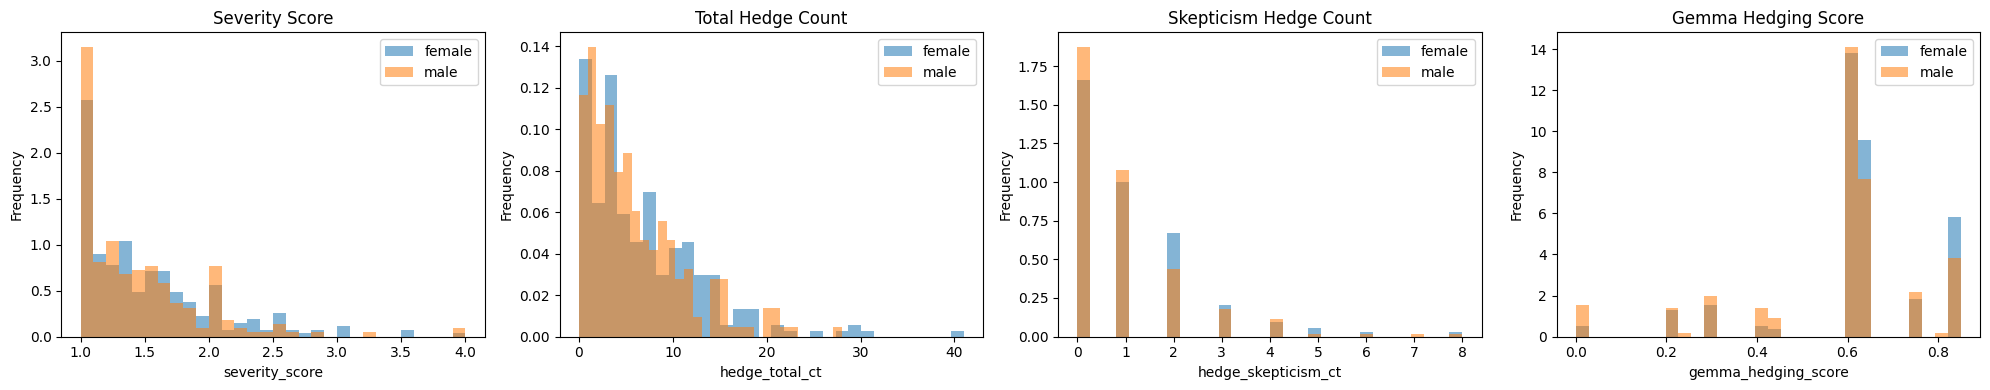

Plot saved.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ensure gemma_hedging_score is available in final_df if the user hasn't re-run the final output cell
if "gemma_hedging_score" not in final_df.columns and "gemma_hedging_score" in df.columns:
    final_df["gemma_hedging_score"] = df["gemma_hedging_score"]

binary_gender = final_df[final_df["gender_label"].isin(["female", "male"])].copy()

print("=" * 60)
print("1. READMISSION RATES BY GENDER")
print("=" * 60)
print(binary_gender.groupby("gender_label")["OUTPUT_LABEL"].agg(["mean", "count"]).round(4))

print("\n" + "=" * 60)
print("2. AVERAGE NLP FEATURES BY GENDER × READMISSION")
print("=" * 60)
feat_cols = ["severity_score", "severity_high_ct", "hedge_total_ct",
             "hedge_skepticism_ct", "hedge_density", "gender_confidence"]

if "gemma_hedging_score" in binary_gender.columns:
    feat_cols.append("gemma_hedging_score")

print(
    binary_gender
    .groupby(["gender_label", "OUTPUT_LABEL"])[feat_cols]
    .mean()
    .round(3)
    .to_string()
)

print("\n" + "=" * 60)
print("3. SKEPTICISM FLAG RATE BY GENDER × READMISSION")
print("=" * 60)
print(
    binary_gender
    .groupby(["gender_label", "OUTPUT_LABEL"])["hedge_skepticism_flag"]
    .mean().round(4)
)

if "gemma_hedging_score" in binary_gender.columns:
    print("\n" + "=" * 60)
    print("4. GEMMA HEDGING VS NLP HEDGING CORRELATION")
    print("=" * 60)
    corr = binary_gender[["hedge_total_ct", "hedge_density", "gemma_hedging_score"]].corr()
    print(corr.round(3))

    print("\n" + "=" * 60)
    print("5. GEMMA HEDGING DECILES BY GENDER")
    print("=" * 60)
    print(binary_gender.groupby("gender_label")["gemma_hedging_score"].describe().round(3))

print("\n" + "=" * 60)
print("6. HEDGING BY SEVERITY TERTILES AND GENDER")
print("=" * 60)
try:
    binary_gender['severity_tertile'] = pd.qcut(binary_gender['severity_score'].dropna(), 3, labels=['Low', 'Medium', 'High'])
    agg_cols = ['hedge_total_ct', 'hedge_density']
    if "gemma_hedging_score" in binary_gender.columns:
        agg_cols.append("gemma_hedging_score")

    print(
        binary_gender
        .groupby(["gender_label", "severity_tertile"])[agg_cols]
        .mean()
        .round(3)
        .to_string()
    )
except ValueError:
    print("Not enough variance in severity score to compute tertiles.")

print("\n" + "=" * 60)
print("7. EXTREME HEDGING DISPARITIES (TOP 20% OF SCORES)")
print("=" * 60)
if "gemma_hedging_score" in binary_gender.columns:
    gemma_80th = binary_gender["gemma_hedging_score"].quantile(0.8)
    binary_gender["high_gemma_hedging"] = (binary_gender["gemma_hedging_score"] >= gemma_80th).astype(int)
    print("Proportion of notes in top 20% of Gemma Hedging by Gender (Threshold >= {:.2f}):".format(gemma_80th))
    print(binary_gender.groupby("gender_label")["high_gemma_hedging"].mean().round(4))

nlp_80th = binary_gender["hedge_density"].quantile(0.8)
binary_gender["high_nlp_hedging"] = (binary_gender["hedge_density"] >= nlp_80th).astype(int)
print("\nProportion of notes in top 20% of NLP Hedge Density by Gender (Threshold >= {:.2f}):".format(nlp_80th))
print(binary_gender.groupby("gender_label")["high_nlp_hedging"].mean().round(4))

# ── Plot: feature distributions by gender ────────────────────────────
plot_feats = [
    ("severity_score", "Severity Score"),
    ("hedge_total_ct", "Total Hedge Count"),
    ("hedge_skepticism_ct", "Skepticism Hedge Count"),
]
if "gemma_hedging_score" in binary_gender.columns:
    plot_feats.append(("gemma_hedging_score", "Gemma Hedging Score"))

n_plots = len(plot_feats)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))
if n_plots == 1: axes = [axes]

for i, (feat, title) in enumerate(plot_feats):
    ax = axes[i]
    for g, grp in binary_gender.groupby("gender_label"):
        grp[feat].dropna().plot(
            kind="hist", bins=30, alpha=0.55, label=g, ax=ax, density=True
        )
    ax.set_title(title)
    ax.set_xlabel(feat)
    ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "nlp_feature_distributions.png", dpi=120, bbox_inches="tight")
plt.show()
print("Plot saved.")

### Advanced Bias Visualizations
Visualizing Hedging Disparities across Severity Tertiles and Extreme Hedging thresholds.

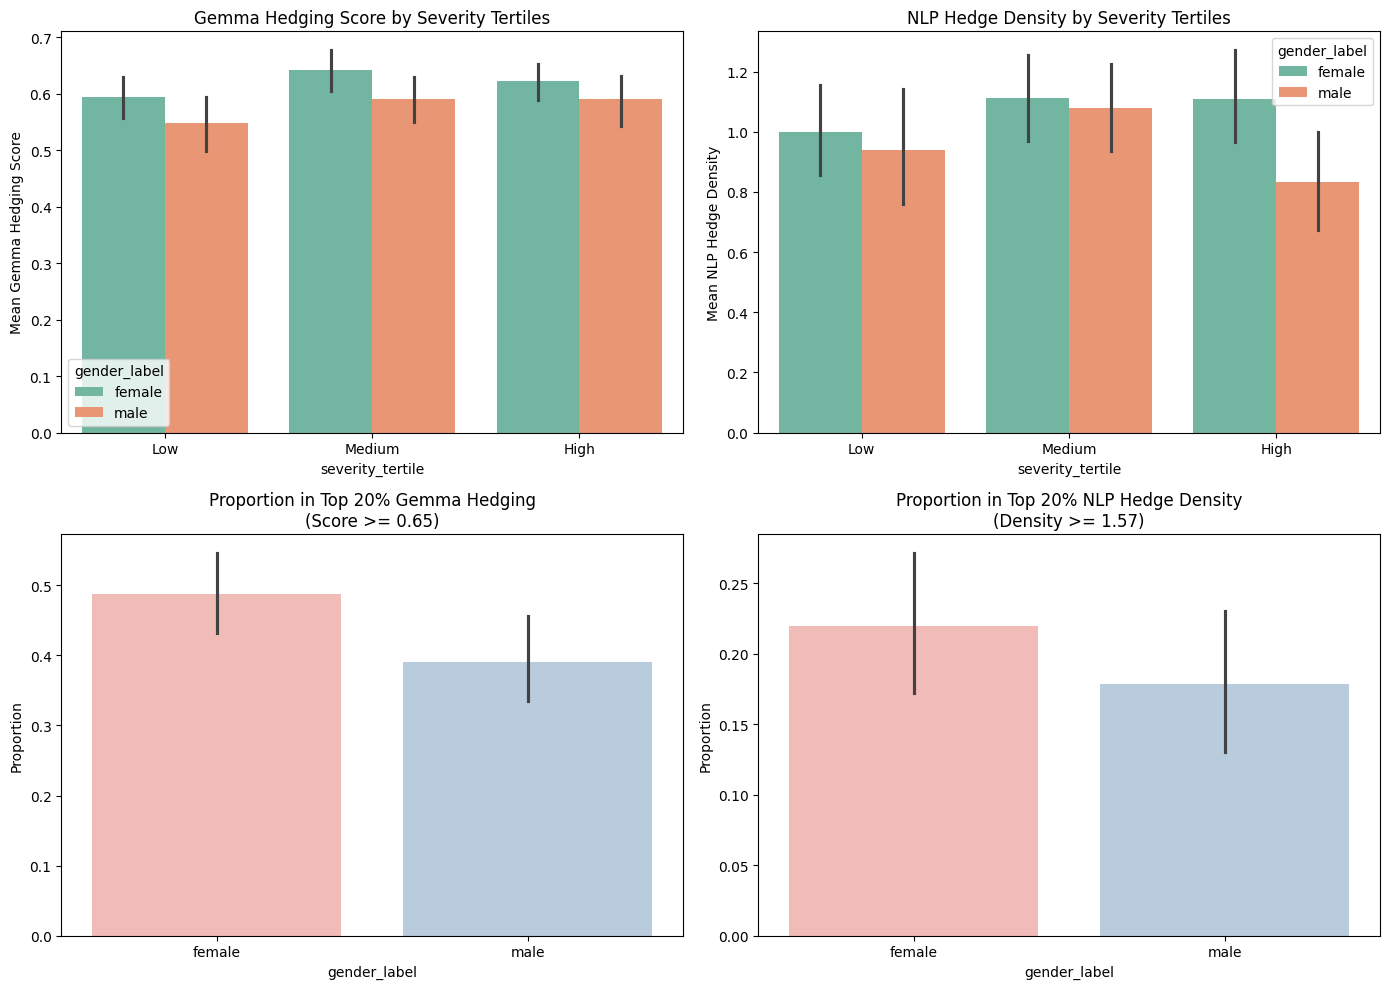

Advanced visualizations saved to outputs/advanced_bias_visualizations.png


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure binary_gender and tertiles are ready
binary_gender = final_df[final_df["gender_label"].isin(["female", "male"])].copy()
try:
    binary_gender['severity_tertile'] = pd.qcut(binary_gender['severity_score'].dropna(), 3, labels=['Low', 'Medium', 'High'])
except ValueError:
    pass # Fallback if not enough variance

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gemma Hedging by Severity Tertile & Gender
if "gemma_hedging_score" in binary_gender.columns and 'severity_tertile' in binary_gender.columns:
    sns.barplot(data=binary_gender, x="severity_tertile", y="gemma_hedging_score", hue="gender_label", ax=axes[0,0], palette="Set2")
    axes[0,0].set_title("Gemma Hedging Score by Severity Tertiles")
    axes[0,0].set_ylabel("Mean Gemma Hedging Score")

# 2. NLP Hedge Density by Severity Tertile & Gender
if 'severity_tertile' in binary_gender.columns:
    sns.barplot(data=binary_gender, x="severity_tertile", y="hedge_density", hue="gender_label", ax=axes[0,1], palette="Set2")
    axes[0,1].set_title("NLP Hedge Density by Severity Tertiles")
    axes[0,1].set_ylabel("Mean NLP Hedge Density")

# 3. Extreme Hedging Proportion (Top 20% Gemma)
if "gemma_hedging_score" in binary_gender.columns:
    gemma_80th = binary_gender["gemma_hedging_score"].quantile(0.8)
    binary_gender["high_gemma_hedging"] = (binary_gender["gemma_hedging_score"] >= gemma_80th).astype(int)
    sns.barplot(data=binary_gender, x="gender_label", y="high_gemma_hedging", ax=axes[1,0], palette="Pastel1")
    axes[1,0].set_title(f"Proportion in Top 20% Gemma Hedging\n(Score >= {gemma_80th:.2f})")
    axes[1,0].set_ylabel("Proportion")

# 4. Extreme Hedging Proportion (Top 20% NLP)
nlp_80th = binary_gender["hedge_density"].quantile(0.8)
binary_gender["high_nlp_hedging"] = (binary_gender["hedge_density"] >= nlp_80th).astype(int)
sns.barplot(data=binary_gender, x="gender_label", y="high_nlp_hedging", ax=axes[1,1], palette="Pastel1")
axes[1,1].set_title(f"Proportion in Top 20% NLP Hedge Density\n(Density >= {nlp_80th:.2f})")
axes[1,1].set_ylabel("Proportion")

plt.tight_layout()
plt.savefig(OUT_DIR / "advanced_bias_visualizations.png", dpi=120, bbox_inches="tight")
plt.show()
print("Advanced visualizations saved to outputs/advanced_bias_visualizations.png")

### 7.1 · Gender Analysis Visualizations
Readmission rates, demographic breakdown, and NLP feature comparisons across gender groups.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
PALETTE = {'female': '#E07B91', 'male': '#5B9BD5'}

bg = final_df[final_df['gender_label'].isin(['female', 'male'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1 — Gender distribution
counts = bg['gender_label'].value_counts()
axes[0].bar(counts.index, counts.values, color=[PALETTE[g] for g in counts.index], edgecolor='black', linewidth=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Gender Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# 2 — Readmission rate by gender
readmit = bg.groupby('gender_label')['OUTPUT_LABEL'].mean()
bars = axes[1].bar(readmit.index, readmit.values, color=[PALETTE[g] for g in readmit.index], edgecolor='black', linewidth=0.5)
for i, v in enumerate(readmit.values):
    axes[1].text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold')
axes[1].set_title('30-Day Readmission Rate by Gender', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Readmission Rate')
axes[1].set_ylim(0, readmit.max() * 1.2)

# 3 — Gender confidence distribution
for g in ['female', 'male']:
    subset = bg[bg['gender_label'] == g]['gender_confidence'].dropna()
    axes[2].hist(subset, bins=20, alpha=0.6, label=g, color=PALETTE[g], edgecolor='black', linewidth=0.5, density=True)
axes[2].set_title('Gender Confidence Score Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Confidence')
axes[2].set_ylabel('Density')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'viz_gender_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_gender_overview.png')

### 7.2 · Severity Analysis Visualizations
Severity score distributions, high vs low severity counts, and severity breakdown by gender and readmission status.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1 — Severity score distribution by gender
for g in ['female', 'male']:
    subset = bg[bg['gender_label'] == g]['severity_score'].dropna()
    axes[0,0].hist(subset, bins=25, alpha=0.6, label=g, color=PALETTE[g], edgecolor='black', linewidth=0.5, density=True)
axes[0,0].set_title('Severity Score Distribution by Gender', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Severity Score')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# 2 — Mean severity by gender x readmission (grouped bar)
sev_means = bg.groupby(['gender_label', 'OUTPUT_LABEL'])['severity_score'].mean().unstack()
sev_means.plot(kind='bar', ax=axes[0,1], color=['#7FBF7F', '#E06666'], edgecolor='black', linewidth=0.5)
axes[0,1].set_title('Mean Severity by Gender × Readmission', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Mean Severity Score')
axes[0,1].set_xlabel('')
axes[0,1].legend(['Not Readmitted', 'Readmitted'], loc='upper right')
axes[0,1].tick_params(axis='x', rotation=0)

# 3 — High severity count by gender (box plot)
sns.boxplot(data=bg, x='gender_label', y='severity_high_ct', palette=PALETTE, ax=axes[1,0])
axes[1,0].set_title('High Severity Mentions (>=4) by Gender', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('')
axes[1,0].set_ylabel('Count of High Severity Mentions')

# 4 — Severity score by readmission status (violin plot)
bg['readmit_label'] = bg['OUTPUT_LABEL'].map({0: 'Not Readmitted', 1: 'Readmitted'})
sns.violinplot(data=bg, x='readmit_label', y='severity_score', hue='gender_label',
               split=True, palette=PALETTE, ax=axes[1,1], inner='quartile')
axes[1,1].set_title('Severity Score: Readmitted vs Not (by Gender)', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('')
axes[1,1].set_ylabel('Severity Score')

plt.tight_layout()
plt.savefig(OUT_DIR / 'viz_severity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_severity_analysis.png')

### 7.3 · Hedging Analysis Visualizations
Hedging density, skepticism flags, and Gemma hedging scores across gender, severity, and readmission status.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1 — Hedge density distribution by gender
for g in ['female', 'male']:
    subset = bg[bg['gender_label'] == g]['hedge_density'].dropna()
    axes[0,0].hist(subset, bins=25, alpha=0.6, label=g, color=PALETTE[g], edgecolor='black', linewidth=0.5, density=True)
axes[0,0].set_title('Hedge Density Distribution by Gender', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Hedge Density')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# 2 — Skepticism flag rate by gender x readmission
skep = bg.groupby(['gender_label', 'OUTPUT_LABEL'])['hedge_skepticism_flag'].mean().unstack()
skep.plot(kind='bar', ax=axes[0,1], color=['#7FBF7F', '#E06666'], edgecolor='black', linewidth=0.5)
axes[0,1].set_title('Skepticism Flag Rate by Gender × Readmission', fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Flag Rate')
axes[0,1].set_xlabel('')
axes[0,1].legend(['Not Readmitted', 'Readmitted'])
axes[0,1].tick_params(axis='x', rotation=0)

# 3 — Hedge total count by gender (box plot)
sns.boxplot(data=bg, x='gender_label', y='hedge_total_ct', palette=PALETTE, ax=axes[0,2])
axes[0,2].set_title('Total Hedge Count by Gender', fontsize=11, fontweight='bold')
axes[0,2].set_xlabel('')
axes[0,2].set_ylabel('Hedge Count')

# 4 — Gemma hedging score by gender (violin)
if 'gemma_hedging_score' in bg.columns:
    sns.violinplot(data=bg, x='gender_label', y='gemma_hedging_score', palette=PALETTE,
                   ax=axes[1,0], inner='quartile')
    axes[1,0].set_title('Gemma Hedging Score by Gender', fontsize=11, fontweight='bold')
    axes[1,0].set_xlabel('')
    axes[1,0].set_ylabel('Gemma Hedging Score')
else:
    axes[1,0].text(0.5, 0.5, 'Gemma scores\nnot available', ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].set_title('Gemma Hedging Score by Gender', fontsize=11, fontweight='bold')

# 5 — Hedging by severity tertile and gender (heatmap)
try:
    bg['severity_tertile'] = pd.qcut(bg['severity_score'].dropna(), 3, labels=['Low', 'Med', 'High'])
    heat_data = bg.groupby(['gender_label', 'severity_tertile'])['hedge_density'].mean().unstack()
    sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlOrRd', ax=axes[1,1], linewidths=0.5)
    axes[1,1].set_title('Mean Hedge Density:\nGender × Severity Tertile', fontsize=11, fontweight='bold')
    axes[1,1].set_ylabel('')
except ValueError:
    axes[1,1].text(0.5, 0.5, 'Insufficient variance\nfor tertiles', ha='center', va='center', transform=axes[1,1].transAxes)

# 6 — Gemma hedging by readmission x gender
if 'gemma_hedging_score' in bg.columns:
    gemma_means = bg.groupby(['gender_label', 'OUTPUT_LABEL'])['gemma_hedging_score'].mean().unstack()
    gemma_means.plot(kind='bar', ax=axes[1,2], color=['#7FBF7F', '#E06666'], edgecolor='black', linewidth=0.5)
    axes[1,2].set_title('Gemma Hedging by Gender × Readmission', fontsize=11, fontweight='bold')
    axes[1,2].set_ylabel('Mean Gemma Hedging Score')
    axes[1,2].set_xlabel('')
    axes[1,2].legend(['Not Readmitted', 'Readmitted'])
    axes[1,2].tick_params(axis='x', rotation=0)
else:
    axes[1,2].text(0.5, 0.5, 'Gemma scores\nnot available', ha='center', va='center', transform=axes[1,2].transAxes)

plt.tight_layout()
plt.savefig(OUT_DIR / 'viz_hedging_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_hedging_analysis.png')

### 7.4 · Combined Fairness Summary
Side-by-side comparison of key disparity metrics across gender groups.

In [ ]:
# Build a summary table of gender disparities
summary = {}
for g in ['female', 'male']:
    subset = bg[bg['gender_label'] == g]
    d = {}
    d['N'] = len(subset)
    d['Readmission Rate'] = subset['OUTPUT_LABEL'].mean()
    d['Mean Severity'] = subset['severity_score'].mean()
    d['Mean Hedge Density'] = subset['hedge_density'].mean()
    d['Skepticism Flag Rate'] = subset['hedge_skepticism_flag'].mean()
    d['Mean Hedge Count'] = subset['hedge_total_ct'].mean()
    if 'gemma_hedging_score' in subset.columns:
        d['Mean Gemma Hedging'] = subset['gemma_hedging_score'].mean()
    summary[g] = d

summary_df = pd.DataFrame(summary).T
summary_df.index.name = 'Gender'

# Display table
print('Gender Disparity Summary')
print('=' * 70)
print(summary_df.round(4).to_string())

# Plot radar / grouped bar of key metrics (normalized for comparison)
plot_cols = ['Readmission Rate', 'Mean Severity', 'Mean Hedge Density', 'Skepticism Flag Rate']
if 'Mean Gemma Hedging' in summary_df.columns:
    plot_cols.append('Mean Gemma Hedging')

x = np.arange(len(plot_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars_f = ax.bar(x - width/2, summary_df.loc['female', plot_cols].values, width,
                label='Female', color=PALETTE['female'], edgecolor='black', linewidth=0.5)
bars_m = ax.bar(x + width/2, summary_df.loc['male', plot_cols].values, width,
                label='Male', color=PALETTE['male'], edgecolor='black', linewidth=0.5)

# Add value labels
for bars in [bars_f, bars_m]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_cols, rotation=15, ha='right')
ax.set_title('Key Metrics Comparison: Female vs Male', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylabel('Value')

plt.tight_layout()
plt.savefig(OUT_DIR / 'viz_fairness_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz_fairness_summary.png')

## 8 · Bias Analysis Inputs

Below is a map from each planned bias analysis to the columns in `nlp_results.parquet` they rely on.

| Analysis | Required columns |
|---|---|
| **Equalized Odds** | `OUTPUT_LABEL`, `gender_label`, model predictions (added later) |
| **Recall Parity** | `OUTPUT_LABEL`, `gender_label`, model predictions (added later) |
| **Counterfactual Fairness** | `cleaned_text`, `counterfactual_text`, `gender_label` |
| **LIME Explainability** | `cleaned_text`, all `gender_*`, `severity_*`, `hedge_*` cols, `OUTPUT_LABEL` |

Run the cell below to print exact column names and dtypes for quick reference.

## 9 · Counterfactual Text Generation

Full counterfactual text is large. We store the swapped text only for rows where `gender_label` is `female` or `male` (unambiguous), and only store the swapped version (not a copy of the original).


In [23]:
_F2M = {
    "she": "he",   "She": "He",   "SHE": "HE",
    "her": "him",  "Her": "Him",  "HER": "HIM",
    "hers": "his", "Hers": "His", "HERS": "HIS",
    "herself": "himself", "Herself": "Himself", "HERSELF": "HIMSELF",
}
_M2F = {v: k for k, v in _F2M.items()}

_ALL_PRONOUNS = list(_F2M.keys()) + list(_M2F.keys())
_PRONOUN_RE   = re.compile(
    r"\b(" + "|".join(re.escape(p) for p in sorted(_ALL_PRONOUNS, key=len, reverse=True)) + r")\b"
)

def _swap_pronouns(text: str, swap_map: Dict[str, str]) -> str:
    return _PRONOUN_RE.sub(lambda m: swap_map.get(m.group(), m.group()), text)


def generate_counterfactual(text: str, gender_label: str) -> str:
    if gender_label == "female":
        return _swap_pronouns(text, _F2M)
    elif gender_label == "male":
        return _swap_pronouns(text, _M2F)
    return ""

print("Generating counterfactual texts")
t0 = time.time()

mask = final_df["gender_label"].isin(["female", "male"])
final_df["counterfactual_text"] = ""
final_df.loc[mask, "counterfactual_text"] = final_df[mask].progress_apply(
    lambda r: generate_counterfactual(r["cleaned_text"], r["gender_label"]),
    axis=1,
)

print(f"Done in {time.time()-t0:.1f}s")
print(f"Rows with counterfactual text: {(final_df['counterfactual_text'] != '').sum():,} / {len(final_df):,}")


Generating counterfactual texts


Testing Gemma on all notes:   0%|          | 0/503 [00:00<?, ?it/s]

Done in 0.2s
Rows with counterfactual text: 503 / 1,000




---



In [ ]:
!zip -r outputs.zip outputs/